#  CNN-Based Road Signs Classification

## Data Cleaning

In [5]:
# CNN-Based Road Signs Classification
import pandas as pd
import os
import shutil

# Path setup
image_root = 'D:/Milestone-3/Indian-Traffic Sign-Dataset/Images'
csv_path = 'D:/Milestone-3/Indian-Traffic Sign-Dataset/traffic_sign.csv'

# Load the original labels CSV
df = pd.read_csv(csv_path)

In [ ]:
# Step 1: Remove duplicate class names (keep the first occurrence)
df = df.drop_duplicates(subset='Name', keep='first')

# Step 2: Get available class folders (as string for matching)
available_class_folders = {int(name) for name in os.listdir(image_root) if name.isdigit()}

# Step 3: Keep only those rows whose ClassId folder exists
df = df[df['ClassId'].isin(available_class_folders)]

# Step 4: Create new class IDs (0 to N-1) and map them
class_mapping = {old: new for new, old in enumerate(df['ClassId'].values)}
df['NewClassId'] = df['ClassId'].map(class_mapping)

# Step 5: Rename image folders to new class IDs
for old_id, new_id in class_mapping.items():
    old_folder = os.path.join(image_root, str(old_id))
    new_folder = os.path.join(image_root, str(new_id))
    
    if old_folder != new_folder and os.path.exists(old_folder):
        if not os.path.exists(new_folder):
            os.rename(old_folder, new_folder)
        else:

            for file in os.listdir(old_folder):
                src_file = os.path.join(old_folder, file)
                dst_file = os.path.join(new_folder, file)
                if os.path.exists(dst_file):
                    os.remove(dst_file)  # Remove existing file to avoid error
                shutil.move(src_file, new_folder)
            os.rmdir(old_folder)

# Step 6: Save cleaned CSV with new ClassIds
df_clean = df[['NewClassId', 'Name']].rename(columns={'NewClassId': 'ClassId'})
df_clean.to_csv('traffic_signs_cleaned.csv', index=False)

print("Dataset cleaned and saved to traffic_signs_cleaned.csv")

Dataset cleaned and saved to traffic_signs_cleaned.csv


## Data Preprocessing

In [ ]:
# %pip install opencv-python

In [ ]:
# %pip install --upgrade numpy tensorflow

In [ ]:
# %pip uninstall numpy h5py -y
# %pip install numpy==1.26.4 h5py==3.10.0


### Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential


In [ ]:
print("NumPy version:", np.__version__)
print("h5py version:", h5py.__version__)
print("TensorFlow version:", tf.__version__)

NumPy version: 1.26.4
h5py version: 3.14.0
TensorFlow version: 2.19.0


In [ ]:
# Set image size
IMG_HEIGHT = 64
IMG_WIDTH = 64

# Paths
image_root = 'D:/Milestone-3/Indian-Traffic Sign-Dataset/Images' 
csv_path = 'traffic_signs_cleaned.csv' 

label_df = pd.read_csv(csv_path)
num_classes = label_df['ClassId'].nunique()

In [ ]:
# Initialize image and label arrays
X = []  # Image data
y = []  # Labels

# Loop through each class folder (0 to 58)
for class_id in label_df['ClassId']:
    class_folder = os.path.join(image_root, str(class_id))
    if not os.path.exists(class_folder):
        continue

    for img_file in os.listdir(class_folder):
        img_path = os.path.join(class_folder, img_file)

        try:
            # 1. Load image using OpenCV
            image = cv2.imread(img_path)

            # 2. Resize image to 64x64
            image = cv2.resize(image, (IMG_WIDTH, IMG_HEIGHT))

            # 3. Normalize image pixels to [0, 1]
            image = image / 255.0

            # 4. Append image and corresponding label
            X.append(image)
            y.append(class_id)
        except:
            print(f"Failed to load image: {img_path}")

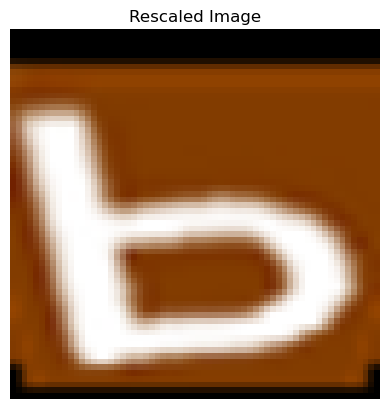

In [ ]:
# 1. Convert to NumPy arrays
X = np.array(X)
y = np.array(y)

# 2. Train-Test Split
X_train_full, X_test, y_train_raw_full, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Train-Validation Split
X_train, X_val, y_train_raw, y_val_raw = train_test_split(
    X_train_full, y_train_raw_full, test_size=0.2, random_state=42, stratify=y_train_raw_full
)

# 4. One-hot encode
y_train = to_categorical(y_train_raw, num_classes=num_classes)
y_val = to_categorical(y_val_raw, num_classes=num_classes)
y_test = to_categorical(y_test_raw, num_classes=num_classes)

# 5. Normalize
X_train = X_train.astype('float32') 
X_val = X_val.astype('float32')
X_test = X_test.astype('float32')

# 6. Display rescaled image
import matplotlib.pyplot as plt

image = X_train[0]
plt.imshow(image / image.max())
plt.title("Rescaled Image")
plt.axis('off')
plt.show()


In [6]:
# 7. Check shapes
print(f"Total images: {X.shape[0]}")
print(f"Training samples: {X_train.shape[0]}, Validation: {X_val.shape[0]}, Testing: {X_test.shape[0]}")
print(f"Image shape: {X_train[0].shape}, Number of classes: {num_classes}")
print("y_train shape:", y_train.shape)

Total images: 13971
Training samples: 8940, Validation: 2236, Testing: 2795
Image shape: (64, 64, 3), Number of classes: 52
y_train shape: (8940, 52)


In [7]:
print("Image shape:", X_train[0].shape)
print("Min pixel value:", X_train[0].min())
print("Max pixel value:", X_train[0].max())


Image shape: (64, 64, 3)
Min pixel value: 0.0
Max pixel value: 1.0


In [8]:
print(X.min(), X.max())


0.0 1.0


## Data Augmentation

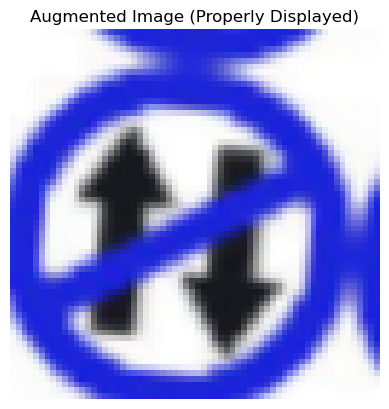

In [ ]:

datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='reflect'
)

aug_iter = datagen.flow(X_train, y_train, batch_size=1)
augmented_images, _ = next(aug_iter)

aug_img = augmented_images[0]
aug_img_rescaled = aug_img / np.max(aug_img)
plt.imshow(aug_img_rescaled)
plt.title("Augmented Image ")
plt.axis('off')
plt.show()



## To check the augmentation

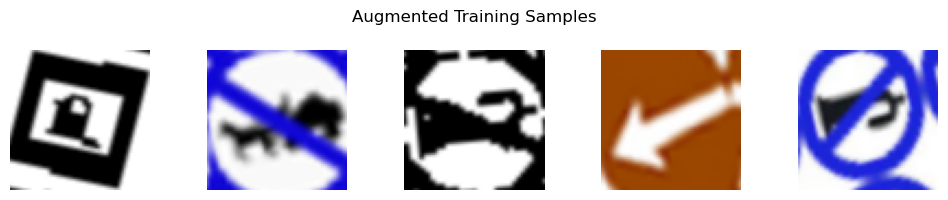

In [ ]:
# Create a generator for augmented images
aug_iter = datagen.flow(X_train, y_train, batch_size=5)
augmented_images, _ = next(aug_iter)

# Plot first 5 augmented images
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    img = augmented_images[i]
    img = img / np.max(img) if np.max(img) > 0 else img
    plt.imshow(img)
    plt.axis('off')

plt.suptitle('Augmented Training Samples')
plt.tight_layout()
plt.show()




## CNN Architecture Design – Input Layer

In [9]:
input_shape = (64, 64, 3)

In [ ]:

# Step 2: Build the CNN Model
model = Sequential()

# 1. Input Layer
model.add(Input(shape=(64, 64, 3)))  # Input shape: 64x64 pixels, 3 color channels (RGB)

# 2. Convolutional Layer 1 + ReLU + MaxPooling
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))  # Output: 64x64x32
model.add(MaxPooling2D(pool_size=(2, 2)))                          # Output: 32x32x32

# 3. Convolutional Layer 2 + ReLU + MaxPooling
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))  # Output: 32x32x64
model.add(MaxPooling2D(pool_size=(2, 2)))                          # Output: 16x16x64

# 4. Convolutional Layer 3 + ReLU + MaxPooling
model.add(Conv2D(128, (3, 3), activation='relu', padding='same')) # Output: 16x16x128
model.add(MaxPooling2D(pool_size=(2, 2)))                          # Output: 8x8x128

# 5. Flatten the output of the last pooling layer
model.add(Flatten())  # Output: 8192 (8*8*128)

# 6. Fully Connected Dense Layer + Dropout
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))  # Prevent overfitting

# 7. Output Layer (Softmax activation for multi-class classification)
model.add(Dense(num_classes, activation='softmax'))  


## Compilation of the Model

In [12]:
model.compile(
    optimizer='adam', 
    loss='categorical_crossentropy', 
    metrics=['accuracy'])

# View model summary
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 52)             │         6,708 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,148,660 (4.38 MB)

 Trainable params: 1,148,660 (4.38 MB)

 Non-trainable params: 0 (0.00 B)

# Training the model

## Splitting the Data

In [13]:
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (8940, 64, 64, 3) (8940, 52)
Validation: (2236, 64, 64, 3) (2236, 52)
Test: (2795, 64, 64, 3) (2795, 52)


## Model Training

In [ ]:
# Early stopping and model checkpoint
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)

# Create data generator (already done earlier)
train_generator = datagen.flow(X_train, y_train, batch_size=32, shuffle=True)

# val_generator = datagen.flow(X_val, y_val, batch_size=32, shuffle=False)

history = model.fit(
    train_generator,
#     validation_data=val_generator,
    validation_data=(X_val, y_val),
    epochs=30,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7623 - loss: 0.6837
Epoch 1: val_accuracy improved from -inf to 0.86628, saving model to best_model.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - accuracy: 0.7623 - loss: 0.6838 - val_accuracy: 0.8663 - val_loss: 0.3475
Epoch 2/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7688 - loss: 0.6483
Epoch 2: val_accuracy improved from 0.86628 to 0.86941, saving model to best_model.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 19s 67ms/step - accuracy: 0.7688 - loss: 0.6483 - val_accuracy: 0.8694 - val_loss: 0.3459
Epoch 3/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.7674 - loss: 0.6563
Epoch 3: val_accuracy did not improve from 0.86941
280/280 ━━━━━━━━━━━━━━━━━━━━ 58s 209ms/step - accuracy: 0.7674 - loss: 0.6563 - val_accuracy: 0.8618 - val_loss: 0.3389
Epoch 4/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.7642 - loss: 0.6531
Epoch 4: val_accuracy did not improve from 0.86941
280/280 ━━━━━━━

## Model Evaluation and Testing

### Evaluating Model Performance

In [ ]:
# Step 4.1: Predict on test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Step 4.2: Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print("Model Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (Macro): {precision:.4f}")
print(f"Recall (Macro): {recall:.4f}")
print(f"F1 Score (Macro): {f1:.4f}")


88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Model Evaluation Metrics:
Accuracy: 0.8837
Precision (Macro): 0.8871
Recall (Macro): 0.8733
F1 Score (Macro): 0.8738


## Confusion Matrix

In [23]:
label_df = pd.read_csv("D:/Milestone-3/traffic_signs_cleaned.csv")  
class_names = label_df['Name'].tolist()

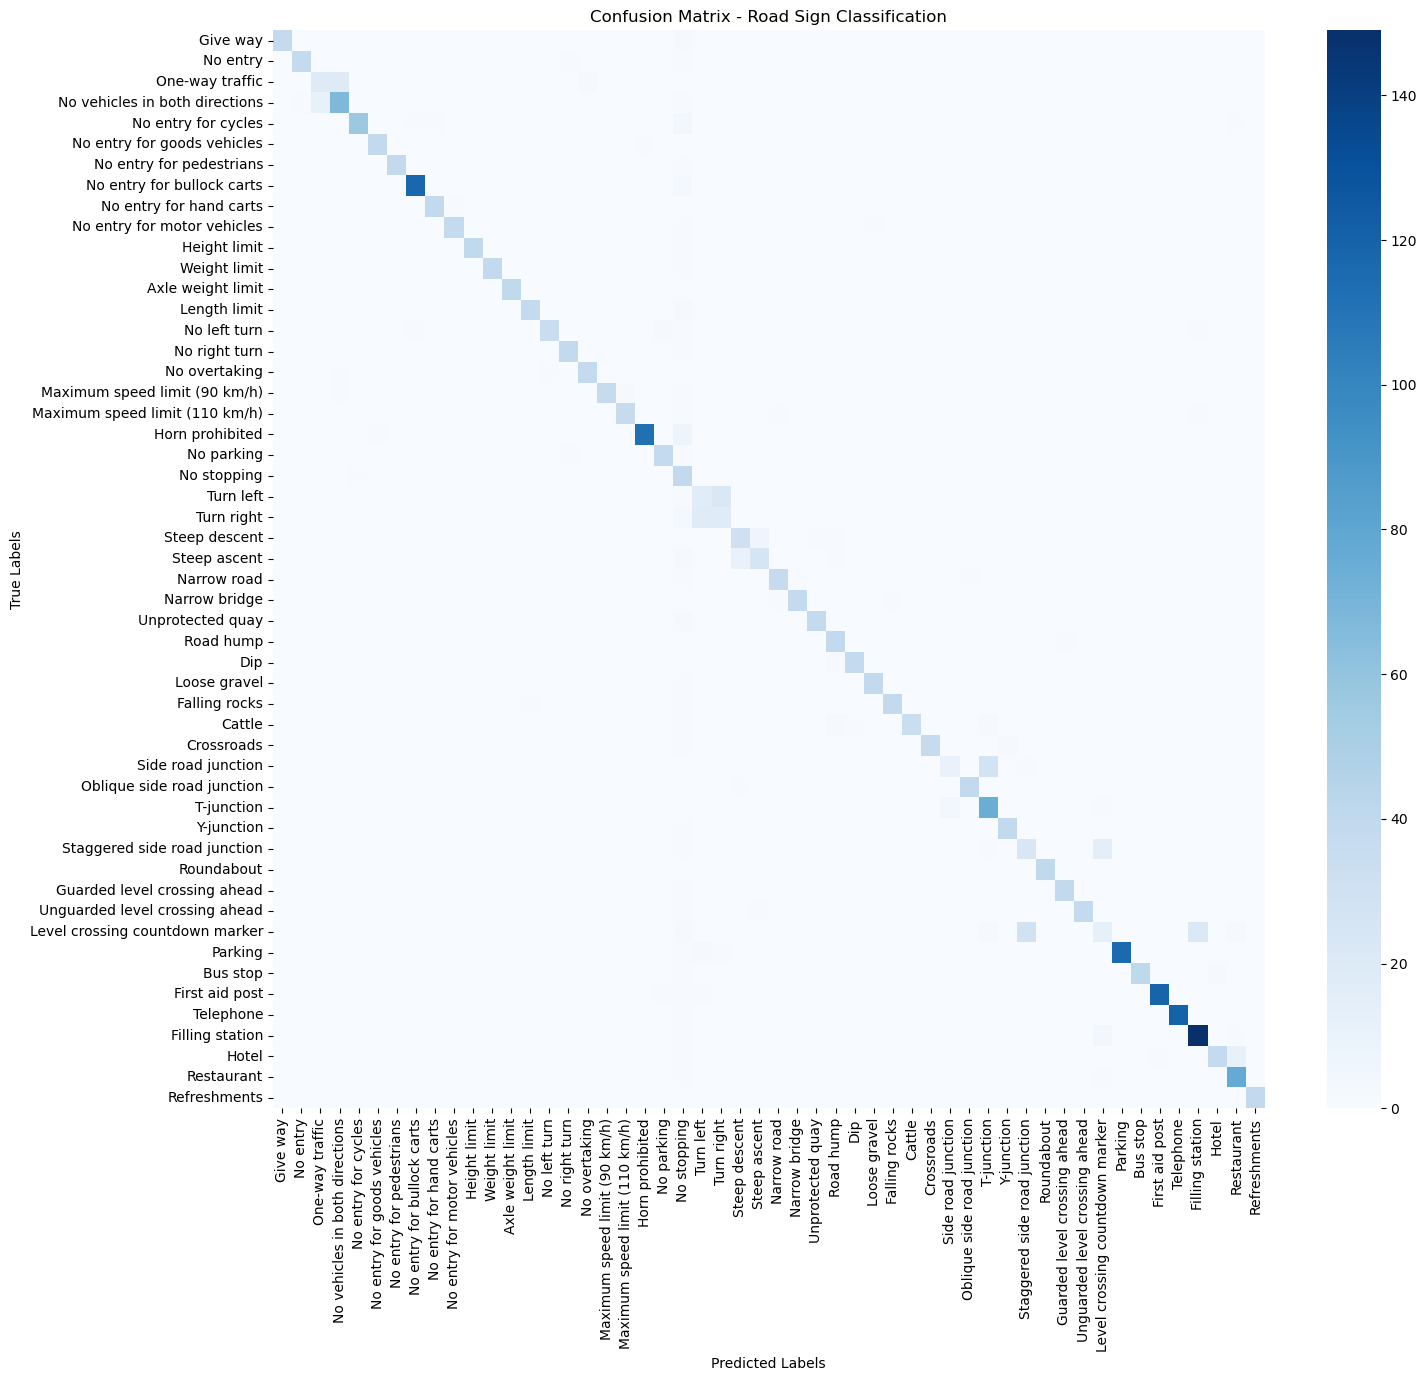

In [ ]:
# Assuming y_true and y_pred are already defined
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, cmap='Blues', annot=False, xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Road Sign Classification')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


In [ ]:
# y_true = true class labels
# y_pred = predicted class labels
print(classification_report(y_true, y_pred))
print("Accuracy:", accuracy_score(y_true, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.95      0.97        40
           1       0.97      0.95      0.96        40
           2       0.61      0.47      0.54        40
           3       0.76      0.83      0.79        81
           4       0.98      0.88      0.93        65
           5       0.97      0.97      0.97        40
           6       1.00      0.97      0.99        40
           7       0.98      0.97      0.97       121
           8       0.97      0.97      0.97        40
           9       0.97      0.95      0.96        40
          10       1.00      0.98      0.99        41
          11       1.00      0.97      0.99        40
          12       1.00      1.00      1.00        40
          13       0.97      0.95      0.96        40
          14       0.97      0.88      0.92        40
          15       0.95      0.97      0.96        40
          16       0.95      0.95      0.95        40
          17       1.00    

## Testing the Model

In [ ]:
# Load trained model
model = load_model("best_model.keras")  # replace with your saved model filename

# Load class names (52 cleaned classes)
label_df = pd.read_csv("D:/Milestone-3/traffic_signs_cleaned.csv")  # cleaned CSV
class_names = label_df['Name'].tolist()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


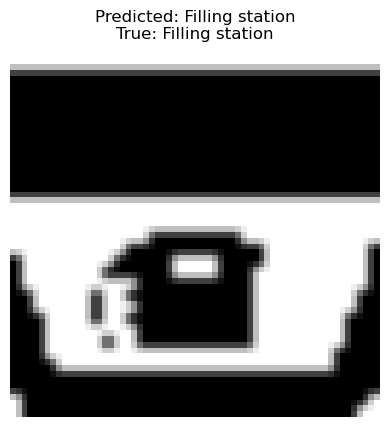

In [41]:
# Pick any index from test set
idx = 10

img_array = X_test[idx]  # Already preprocessed
img_input = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_input)
predicted_class = np.argmax(prediction)
predicted_label = class_names[predicted_class]

# Get true label
true_class = np.argmax(y_test[idx])  # convert one-hot to class index
true_label = class_names[true_class]

# Show the image
plt.imshow(X_test[idx])
plt.title(f"Predicted: {predicted_label}\nTrue: {true_label}")
plt.axis('off')
plt.show()


## Hyperparameter Tuning and Model Optimization

In [43]:
# pip install scikeras

In [ ]:
def create_model(learning_rate=0.001, filters=32, kernel_size=3, dropout_rate=0.3):
    model = Sequential()
    model.add(Input(shape=(64, 64, 3)))  # Use Input here instead of input_shape inside Conv2D
    model.add(Conv2D(filters, (kernel_size, kernel_size), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(filters * 2, (kernel_size, kernel_size), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation='softmax'))  

    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model


## Model Optimization

In [70]:
model = KerasClassifier(model=create_model, verbose=0, epochs=10, batch_size=32)

param_grid = {
    "model__learning_rate": [0.001, 0.0005, 0.0001],
    "model__filters": [32, 64],
    "model__kernel_size": [3, 5],
    "model__dropout_rate": [0.2, 0.3, 0.4]
}


In [71]:
search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=5,
    cv=3,
    verbose=2,
    random_state=42
)

search.fit(X_train, y_train)


Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END model__dropout_rate=0.4, model__filters=64, model__kernel_size=5, model__learning_rate=0.0001; total time= 4.8min
[CV] END model__dropout_rate=0.4, model__filters=64, model__kernel_size=5, model__learning_rate=0.0001; total time= 4.9min
[CV] END model__dropout_rate=0.4, model__filters=64, model__kernel_size=5, model__learning_rate=0.0001; total time= 4.3min
[CV] END model__dropout_rate=0.3, model__filters=32, model__kernel_size=3, model__learning_rate=0.0005; total time= 1.0min
[CV] END model__dropout_rate=0.3, model__filters=32, model__kernel_size=3, model__learning_rate=0.0005; total time= 1.0min
[CV] END model__dropout_rate=0.3, model__filters=32, model__kernel_size=3, model__learning_rate=0.0005; total time= 1.1min
[CV] END model__dropout_rate=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.0001; total time= 1.1min
[CV] END model__dropout_rate=0.4, model__filters=32, model__kernel_size=3, mode

RandomizedSearchCV(cv=3,
                   estimator=KerasClassifier(batch_size=32, epochs=10, model=<function create_model at 0x000001A75AD1C2C0>, verbose=0),
                   n_iter=5,
                   param_distributions={'model__dropout_rate': [0.2, 0.3, 0.4],
                                        'model__filters': [32, 64],
                                        'model__kernel_size': [3, 5],
                                        'model__learning_rate': [0.001, 0.0005,
                                                                 0.0001]},
                   random_state=42, verbose=2)

In [ ]:
# Step 1: Get Best Hyperparameters
best_params = search.best_params_
print("Best Parameters:", best_params)

# Step 2: Create Final Model with Best Params
final_model = create_model(
    learning_rate=best_params['model__learning_rate'],
    filters=best_params['model__filters'],
    kernel_size=best_params['model__kernel_size'],
    dropout_rate=best_params['model__dropout_rate']
)

# Step 3: Train Final Model
history = final_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),  # Or use validation_split=0.2
    epochs=10,
    batch_size=32
)

# Step 4: Evaluate on Test Set
test_loss, test_acc = final_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# Step 5: Save the Final Model
final_model.save("best_model_final.keras")


Best Parameters: {'model__learning_rate': 0.0005, 'model__kernel_size': 5, 'model__filters': 32, 'model__dropout_rate': 0.3}
Epoch 1/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 19s 62ms/step - accuracy: 0.1873 - loss: 3.2569 - val_accuracy: 0.5524 - val_loss: 1.6524
Epoch 2/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - accuracy: 0.5352 - loss: 1.6680 - val_accuracy: 0.6919 - val_loss: 1.1068
Epoch 3/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 17s 60ms/step - accuracy: 0.6806 - loss: 1.0873 - val_accuracy: 0.7492 - val_loss: 0.8959
Epoch 4/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 17s 61ms/step - accuracy: 0.7463 - loss: 0.8238 - val_accuracy: 0.7746 - val_loss: 0.7748
Epoch 5/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step - accuracy: 0.7961 - loss: 0.6516 - val_accuracy: 0.7818 - val_loss: 0.7272
Epoch 6/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step - accuracy: 0.8280 - loss: 0.5311 - val_accuracy: 0.7882 - val_loss: 0.7094
Epoch 7/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 17s 62ms/step - accuracy: 0.8508 - loss: 0.4636 - val_a